Random Forest Model — Residential 3 Energy Forecasting
Objective

Build a Random Forest regression model to predict household energy consumption for Residential 3 using the cleaned and preprocessed time-series dataset.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt
import seaborn as sns

Loading the dataset

In [10]:
df = pd.read_csv(r"C:\Users\test\OneDrive\Documents\GitHub\DataScienceCapstone\data\residential3_cleaned.csv")

# Convert timestamp column
# Change column name if needed

df['utc_timestamp'] = pd.to_datetime(df['utc_timestamp'])

# Sort by time

df = df.sort_values('utc_timestamp')

# Preview
print(df.head())

              utc_timestamp  DE_KN_residential3_circulation_pump  \
0 2016-02-28 17:30:00+00:00                                0.018   
1 2016-02-28 17:45:00+00:00                                0.018   
2 2016-02-28 18:00:00+00:00                                0.018   
3 2016-02-28 18:15:00+00:00                                0.018   
4 2016-02-28 18:30:00+00:00                                0.018   

   DE_KN_residential3_dishwasher  DE_KN_residential3_freezer  \
0                          0.001                         0.0   
1                          0.000                         0.0   
2                          0.001                         0.0   
3                          0.001                         0.0   
4                          0.000                         0.0   

   DE_KN_residential3_grid_export  DE_KN_residential3_grid_import  \
0                             0.0                           0.145   
1                             0.0                           0.180   

Feature engineering

In [11]:
# Time-based features

df['hour'] = df['utc_timestamp'].dt.hour
df['day'] = df['utc_timestamp'].dt.day
df['month'] = df['utc_timestamp'].dt.month
df['day_of_week'] = df['utc_timestamp'].dt.dayofweek

df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

Creating Lag Features

In [13]:
# Example target column
# Replace with your actual target
TARGET = 'DE_KN_residential3_grid_import'

# Previous timestep values

df['lag_1'] = df[TARGET].shift(1)
df['lag_4'] = df[TARGET].shift(4)     # 1 hour back (15 min intervals)
df['lag_96'] = df[TARGET].shift(96)   # 24 hours back

Rolling Statistics

In [14]:
# Rolling averages

df['rolling_mean_4'] = df[TARGET].rolling(window=4).mean()
df['rolling_mean_96'] = df[TARGET].rolling(window=96).mean()

df = df.dropna()

Define features and Target

In [15]:
# Target variable

y = df[TARGET]

# Features
feature_cols = [
    'hour',
    'day',
    'month',
    'day_of_week',
    'is_weekend',
    'lag_1',
    'lag_4',
    'lag_96',
    'rolling_mean_4',
    'rolling_mean_96'
]

# Add appliance columns if available
optional_features = [
    'dishwasher',
    'washing_machine',
    'solar_generation'
]

for col in optional_features:
    if col in df.columns:
        feature_cols.append(col)

X = df[feature_cols]

print(X.head())

     hour  day  month  day_of_week  is_weekend  lag_1  lag_4  lag_96  \
96     17   29      2            0           0  0.161  0.148   0.145   
97     17   29      2            0           0  0.158  0.140   0.180   
98     18   29      2            0           0  0.170  0.160   0.180   
99     18   29      2            0           0  0.216  0.161   0.238   
100    18   29      2            0           0  0.473  0.158   0.230   

     rolling_mean_4  rolling_mean_96  
96          0.15475         0.140021  
97          0.16225         0.139917  
98          0.17625         0.140292  
99          0.25425         0.142740  
100         0.40500         0.148271  


Train Test split

In [16]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print(X_train.shape)
print(X_test.shape)

(38011, 10)
(9503, 10)


Train Random Forest Model

In [17]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [18]:
y_pred = rf_model.predict(X_test)

Model Evaluation

In [19]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

MAE: 0.0244
RMSE: 0.0529
R² Score: 0.7500


Feature Importance

In [20]:
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

           Feature  Importance
8   rolling_mean_4    0.792542
5            lag_1    0.053626
6            lag_4    0.052997
7           lag_96    0.023781
9  rolling_mean_96    0.023439
0             hour    0.018018
1              day    0.015635
2            month    0.010952
3      day_of_week    0.007907
4       is_weekend    0.001103


Plot feature importance

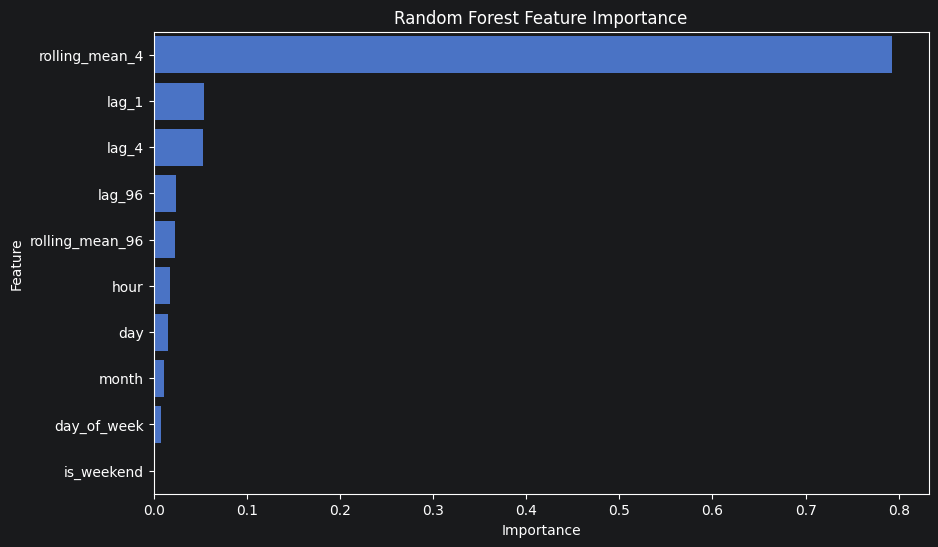

In [21]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title('Random Forest Feature Importance')
plt.show()

Next we will compare the actual vs the predicted plot to see the model performance

<function matplotlib.pyplot.show(close=None, block=None)>

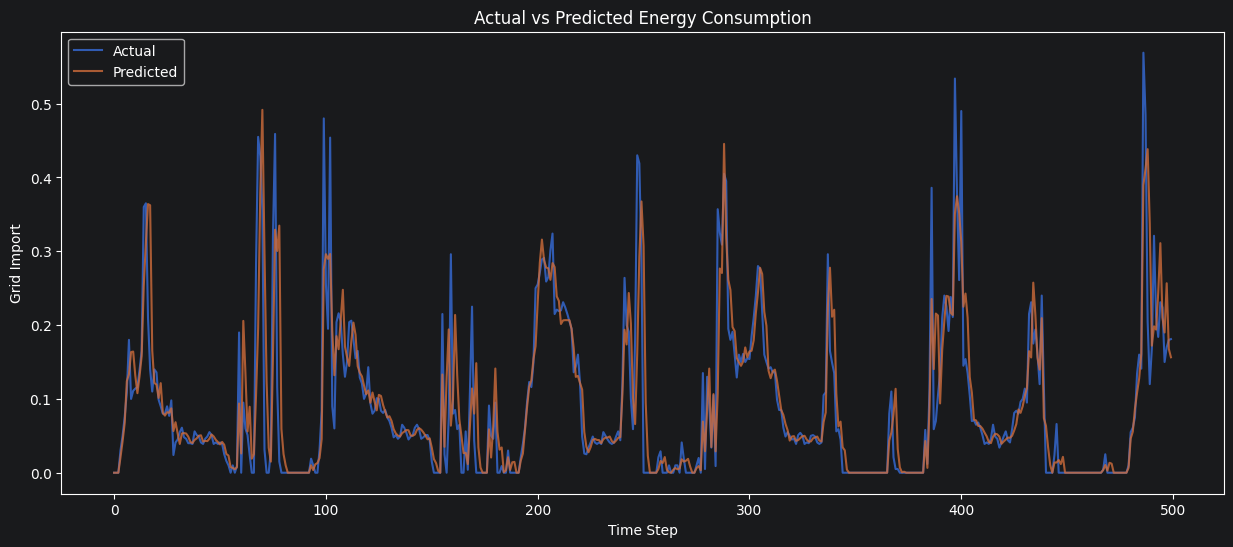

In [22]:
plt.figure(figsize=(15, 6))

plt.plot(
    y_test.values[:500],
    label='Actual',
    alpha=0.8
)

plt.plot(
    y_pred[:500],
    label='Predicted',
    alpha=0.8
)

plt.title('Actual vs Predicted Energy Consumption')
plt.xlabel('Time Step')
plt.ylabel('Grid Import')
plt.legend()
plt.show